In [180]:
import pandas as pd
import numpy as np
import sklearn


df = pd.read_csv("../data/data_transformed_main.csv").set_index(["ID на сайте", "Источник"])
df["Вид объекта"] = df["Вид объекта"].replace({
    'Офис/Здание': 'Офис / Здание',
    'Торговое / Свободное назначение': 'Торговое / Свободного назначения',
    'Торговое / свободного вида': 'Торговое / Свободного назначения',
    'Торговое/Свободного назначения': 'Торговое / Свободного назначения',
})
df["Москва?"] = df["Москва?"].replace({'False': 0, 'True': 1})
df.head()

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Цена / м2,Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офис / Здание,23.0,1500.0,0.0
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое / Свободного назначения,107.0,1500.0,0.0
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офис / Здание,830.0,1478.0,0.0
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офис / Здание,160.0,1478.0,0.0
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офис / Здание,1040.0,1478.0,0.0


In [181]:
df.dtypes

Цена                       float64
Дата                        object
Тип автора                  object
Город                       object
Метро/Район                 object
Адрес                       object
Описание                    object
lat                        float64
lng                        float64
URL                         object
Ссылки на картинки          object
Расстояние до метро, км    float64
Этаж                       float64
Этажность здания           float64
Вид объекта                 object
Общая площадь              float64
Цена / м2                  float64
Москва?                     object
dtype: object

In [182]:
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, TargetEncoder,
    StandardScaler, MinMaxScaler, RobustScaler,
)

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

In [183]:
df.columns

Index(['Цена', 'Дата', 'Тип автора', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь', 'Цена / м2', 'Москва?'],
      dtype='object')

In [184]:
df.iloc[:2]["Тип автора"]

ID на сайте  Источник
321970859    cian.ru        Агентство
323570959    cian.ru     Частное лицо
Name: Тип автора, dtype: object

In [185]:
pd.get_dummies(df['Тип автора']).astype(int)

,,Агентство,Частное лицо
ID на сайте,Источник,,
321970859,cian.ru,1,0
323570959,cian.ru,0,1
319937619,cian.ru,1,0
319936797,cian.ru,1,0
319938233,cian.ru,1,0
...,...,...,...
4750280767,avito.ru,1,0
4750437026,avito.ru,1,0
4750004434,avito.ru,1,0


In [186]:
ohe = OneHotEncoder().fit(df[['Тип автора']])
ohe.transform(df[['Тип автора']]).toarray()

ValueError: Pandas output does not support sparse data. Set sparse_output=False to output pandas dataframes or disable Pandas output via` ohe.set_output(transform="default").

In [187]:
ord_enc = OrdinalEncoder().fit(df[['Вид объекта']])
ord_enc.transform(df[['Вид объекта']])

,,Вид объекта
ID на сайте,Источник,
321970859,cian.ru,0.0
323570959,cian.ru,1.0
319937619,cian.ru,0.0
319936797,cian.ru,0.0
319938233,cian.ru,0.0
...,...,...
4750280767,avito.ru,0.0
4750437026,avito.ru,0.0
4750004434,avito.ru,0.0


In [188]:
ord_enc.categories_

[array(['Офис / Здание', 'Торговое / Свободного назначения'], dtype=object)]

In [189]:
df.groupby("Вид объекта")["Цена"].mean()

Вид объекта
Офис / Здание                       496837.200929
Торговое / Свободного назначения    277255.474716
Name: Цена, dtype: float64

In [190]:
tar_enc = TargetEncoder(smooth=5).fit(df[['Вид объекта']], df["Цена"])
tar_enc.transform(df[['Вид объекта']])

,,Вид объекта
ID на сайте,Источник,
321970859,cian.ru,496754.842922
323570959,cian.ru,277272.212739
319937619,cian.ru,496754.842922
319936797,cian.ru,496754.842922
319938233,cian.ru,496754.842922
...,...,...
4750280767,avito.ru,496754.842922
4750437026,avito.ru,496754.842922
4750004434,avito.ru,496754.842922


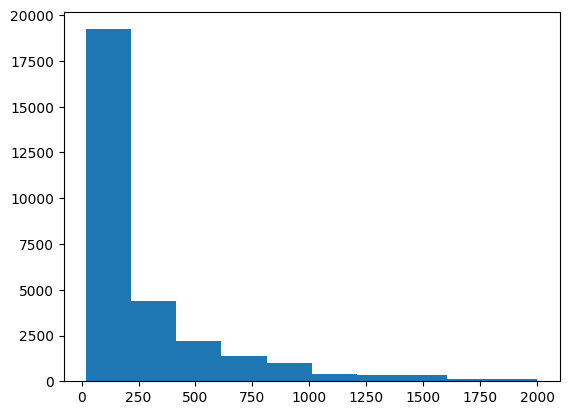

In [191]:
import matplotlib.pyplot as plt

plt.hist(df["Общая площадь"])
plt.show()

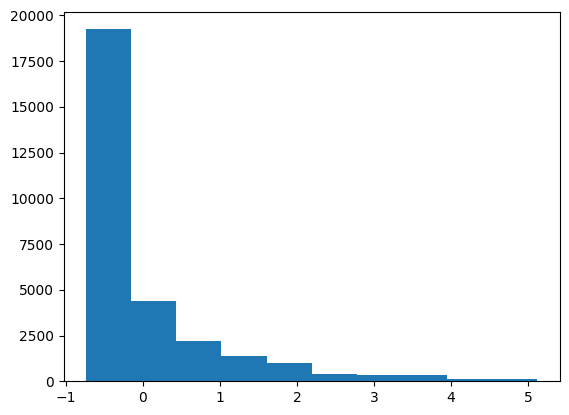

In [192]:
plt.hist(StandardScaler().fit_transform(df[["Общая площадь"]]))
plt.show()

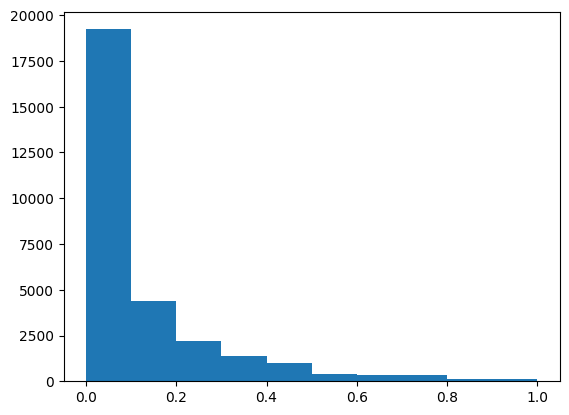

In [193]:
plt.hist(MinMaxScaler().fit_transform(df[["Общая площадь"]]))
plt.show()

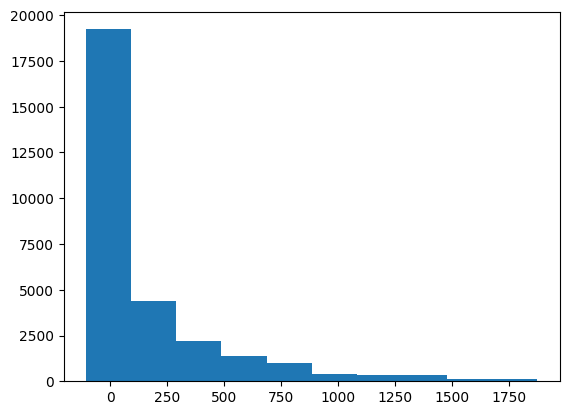

In [194]:
plt.hist(RobustScaler(quantile_range=(0.2, 0.8)).fit_transform(df[["Общая площадь"]]))
plt.show()

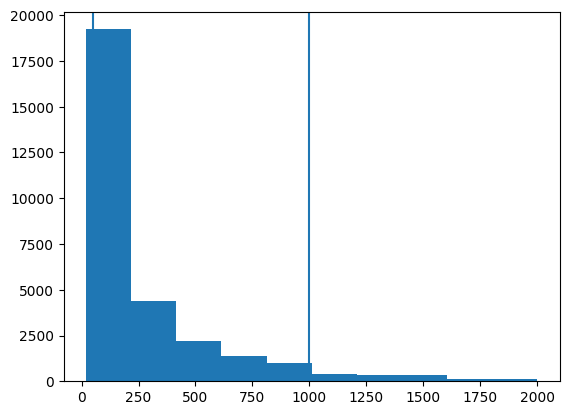

In [195]:
plt.hist(df["Общая площадь"])
plt.axvline(df["Общая площадь"].quantile(0.2))
plt.axvline(df["Общая площадь"].quantile(0.95))
plt.show()

In [196]:
df.columns

Index(['Цена', 'Дата', 'Тип автора', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь', 'Цена / м2', 'Москва?'],
      dtype='object')

In [197]:
from sklearn import set_config
from sklearn.compose import ColumnTransformer

set_config(transform_output="pandas")

ct = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км"]),
        ("onehot", OneHotEncoder(sparse_output=False), ["Вид объекта"]),
        ("ordinal", OrdinalEncoder(), ["Тип автора"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

ct.fit(df)

,transformers,"[('scale', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [198]:
ct.transform(df)

,,scale__Общая площадь,"scale__Расстояние до метро, км",onehot__Вид объекта_Офис / Здание,onehot__Вид объекта_Торговое / Свободного назначения,ordinal__Тип автора,remainder__Цена,remainder__Дата,remainder__Город,remainder__Метро/Район,remainder__Адрес,remainder__Описание,remainder__lat,remainder__lng,remainder__URL,remainder__Ссылки на картинки,remainder__Этаж,remainder__Этажность здания,remainder__Цена / м2,remainder__Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,
321970859,cian.ru,-0.727409,-0.071871,1.0,0.0,0.0,34500.0,2025-12-17 08:36:40,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,4.0,4.0,1500.000000,0.0
323570959,cian.ru,-0.479083,-0.071871,0.0,1.0,1.0,160500.0,2025-12-17 08:36:40,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,1.0,1.0,1500.000000,0.0
319937619,cian.ru,1.658292,-0.071871,1.0,0.0,0.0,1226740.0,2025-12-17 08:36:40,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,2.0,6.0,1478.000000,0.0
319936797,cian.ru,-0.322401,-0.071871,1.0,0.0,0.0,236480.0,2025-12-17 08:36:39,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,2.0,6.0,1478.000000,0.0
319938233,cian.ru,2.279106,-0.071871,1.0,0.0,0.0,1537120.0,2025-12-17 08:36:38,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,2.0,6.0,1478.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4750280767,avito.ru,0.730322,-0.871338,1.0,0.0,0.0,736325.0,2025-02-28 14:19:30,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",НАЗВАНИЕ: Офисное помещение 516.12 кв.м от соб...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,https://30.img.avito.st/image/1/1.AlU-sba5rrwI...,1.0,NaN,1426.709940,0.0
4750437026,avito.ru,-0.256772,-0.838334,1.0,0.0,0.0,270000.0,2025-02-28 14:19:23,Котельники,Котельники,"Московская обл., Котельники, Дзержинское ш., 2",НАЗВАНИЕ: Офисное помещение 182.24 кв.м от соб...,55.654477,37.856443,https://www.avito.ru/kotelniki/kommercheskaya_...,https://10.img.avito.st/image/1/1.xz3K9La5a9T8...,5.0,NaN,1481.888035,0.0
4750004434,avito.ru,0.744808,-0.871338,1.0,0.0,0.0,743442.0,2025-02-28 14:19:06,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",НАЗВАНИЕ: Офисное помещение 521 кв.м от собств...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,https://70.img.avito.st/image/1/1.y5athra5Z3-b...,1.0,NaN,1426.952015,0.0


In [199]:
df.shape

(29559, 18)

In [200]:
from sklearn.model_selection import train_test_split

y = df["Цена"].copy()
X = df[["Общая площадь", "Расстояние до метро, км", "Вид объекта", "Тип автора", "Москва?"]].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=X["Вид объекта"])

In [201]:
X_train["Вид объекта"].value_counts() / X_train.shape[0] * 100

Вид объекта
Торговое / Свободного назначения    68.929586
Офис / Здание                       31.070414
Name: count, dtype: float64

In [202]:
X_test["Вид объекта"].value_counts() / X_test.shape[0] * 100

Вид объекта
Торговое / Свободного назначения    68.930988
Офис / Здание                       31.069012
Name: count, dtype: float64

In [203]:
X_test.isna().sum()

Общая площадь                 0
Расстояние до метро, км    2207
Вид объекта                   0
Тип автора                    0
Москва?                       0
dtype: int64

In [204]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy="constant", fill_value=100, add_indicator=True).fit(X_train[["Расстояние до метро, км"]])
X_train_fillna = si.transform(X_train[["Расстояние до метро, км"]])
X_test_fillna = si.transform(X_test[["Расстояние до метро, км"]])

In [205]:
X_train = pd.concat([X_train.drop("Расстояние до метро, км", axis=1), X_train_fillna], axis=1)
X_test = pd.concat([X_test.drop("Расстояние до метро, км", axis=1), X_test_fillna], axis=1)

X_train.head()

,,Общая площадь,Вид объекта,Тип автора,Москва?,"Расстояние до метро, км","missingindicator_Расстояние до метро, км"
ID на сайте,Источник,,,,,,
313599809,cian.ru,48.0,Торговое / Свободного назначения,Агентство,0.0,0.667,0.0
310768507,cian.ru,858.0,Торговое / Свободного назначения,Агентство,0.0,100.000,1.0
7494860636,avito.ru,52.1,Торговое / Свободного назначения,Частное лицо,0.0,100.000,1.0
322062110,cian.ru,61.0,Торговое / Свободного назначения,Агентство,0.0,18.333,0.0
7300722011,avito.ru,656.0,Офис / Здание,Частное лицо,0.0,100.000,1.0


In [206]:
ct = ColumnTransformer(
    transformers=[
        
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км"]),
        ("onehot", OneHotEncoder(sparse_output=False), ["Вид объекта"]),
        ("ordinal", OrdinalEncoder(), ["Тип автора"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

ct.fit(X_train)

,transformers,"[('scale', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [207]:
X_train_pre = ct.transform(X_train)
X_test_pre = ct.transform(X_test)

In [208]:
model = LinearRegression().fit(X_train_pre, y_train)

In [209]:
y_pred = model.predict(X_train_pre)
y_test_pred = model.predict(X_test_pre)

In [210]:
r2_score(y_train, y_pred), rmse(y_train, y_pred), mape(y_train, y_pred)

(0.727181722451856, 222355.47945786893, 0.7018625683246349)

In [211]:
r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

(0.72408327845947, 216684.91050593805, 0.7083476435569545)